In [ ]:
import os
from collections import defaultdict

import gensim.downloader as api
from gensim.models import Word2Vec
import networkx as nx 
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

### Evaluation

In [2]:
# Read in graphs
graph_weighted = nx.read_gexf('data/graph_weighted_with_probs.gexf')
graph_original = nx.read_gexf('data/pos_tagged_graph_original.gexf')

In [3]:
# Fetch embeddings, inlcuding Google's for comparison
models = {}
models['google_word2vec'] = api.load('word2vec-google-news-300')
models['weighted_window_5'] = Word2Vec.load("data/weighted_graph_embeddings_window_5.model").wv
models['weighted_window_10'] = Word2Vec.load("data/weighted_graph_embeddings_window_10.model").wv
models['unweighted_window_5'] = Word2Vec.load("data/unweighted_graph_embeddings_window_5.model").wv
models['unweighted_window_10'] = Word2Vec.load("data/unweighted_graph_embeddings_window_10.model").wv

graph_models = [
    'unweighted_window_5', 
    'unweighted_window_10', 
    'weighted_window_5', 
    'weighted_window_10'
    ]

google_models = ['google_word2vec']

In [4]:
# Create an index mapping words to nodes that match
word_node_index = defaultdict(list)
for node, data in graph_weighted.nodes(data=True):
    if data['type'] != 'meta':
        word = data['value']
        word_node_index[word].append((node, data))


In [5]:
def get_nodes(word, *pos_info):
    nodes = [n for n, _ in word_node_index[word.lower()]]
    if len(pos_info) == 0:
        return nodes

    valid_nodes = []
    for node in nodes:
        match = True
        for item in pos_info:
            if f"'{item}'" not in node:
                match=False
                break
        if match:
            valid_nodes.append(node)

    return valid_nodes

#### Analogy Tests

##### Prep

In [6]:
# read in analogies
analogies_folder = 'analogies'
analogies_master = {}
for analogy_file in os.listdir(analogies_folder):
    category = analogy_file[:-4]
    analogies_master[category] = pd.read_table(os.path.join(analogies_folder, analogy_file), sep=" ", header=None)
    analogies_master[category].columns = ['w1', 'r1', 'w2', 'r2']
    

In [7]:
# get and save a list of all nodes for words in the analogies
words_not_in_graph = []
for category, tests in analogies_master.items():
    for ind, row in tqdm(tests.iterrows(), category, total=len(tests)):
        for word in row:
            if word not in word_node_index:
                if len(get_nodes(word)) == 0:
                    words_not_in_graph.append(word)

print(f'Words Not in Graph: {words_not_in_graph}')

superlative: 100%|██████████| 1122/1122 [00:00<00:00, 79111.20it/s]

Words Not in Graph: ['Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmop

In [8]:
# clean analogies
for category, tests in analogies_master.items():
    analogies_master[category] = tests[~tests.isin(words_not_in_graph).any(axis=1)]

##### Tests

In [9]:
google_words = set([word.lower() for word in models['google_word2vec'].index_to_key])

In [10]:
# create lists of analogies, but in a format of the embeddings models can take. 
# for graphical models, this generates analogies using nodes.
# for google, this generates analogies using words themselves.
# filters out analogies that have words that are either not in the graph or not in google's list
analogy_nodes = defaultdict(list)
analogy_google = defaultdict(list)
for category, tests in analogies_master.items():
    for ind, row in tqdm(tests.iterrows(), category, total=len(tests)):
        w1, r1, w2, r2 = row
        w1_nodes = get_nodes(w1)
        r1_nodes = get_nodes(r1)
        w2_nodes = get_nodes(w2)
        r2_nodes = get_nodes(r2)

        nodes1_3 = set()
        for node1 in w1_nodes:     # for each node that is the first word in the analogy
            try:
                node3 = [node for node in w2_nodes if eval(node)[1:] == eval(node1)[1:]][0]    # find the node for the third word that has the same pos
                nodes1_3.add((node1, node3))
            except IndexError:
                continue
            
            
        nodes2_4 = set() 
        for node2 in r1_nodes:    # then for each word that is the second word in the analogy
            try:
                node4 = [node for node in r2_nodes if eval(node)[1:] == eval(node2)[1:]][0]    # find the node for the third word that has the same pos
                nodes2_4.add((node2, node4))
            except IndexError:
                continue

        for node1, node3 in nodes1_3:
            for node2, node4 in nodes2_4:
                if (eval(node1)[0] in google_words) and (eval(node2)[0] in google_words) \
                        and (eval(node3)[0] in google_words) and (eval(node4)[0] in google_words):
                    
                    analogy_nodes[category].append((node1, node2, node3, node4))
                    analogy_google[category].append((w1, r1, w2, r2))
                    
                    
            

superlative: 100%|██████████| 1056/1056 [00:00<00:00, 2808.01it/s]


In [11]:

# function to calculate accuracies using analogies for the different models
def calculate_analogy_accuracy(analogies_list, model_keys, accuracies):
    for category, analogies in analogies_list.items():
        for analogy in tqdm(analogies, f'calculating for {category}...'):
            w1, r1, w2, r2 = analogy
            
            for model_key in model_keys:
                model = models[model_key]
                
                try:
                    test_vect = model[w1] - model[r1] + model[w2]
                except KeyError:
                    print(model_key, w1, r1, w2, r2)
                    continue
                most_similar = [item[0] for item in model.similar_by_vector(test_vect, topn=10)]
    
                if r2 in most_similar[:1]:
                    accuracies[model_key][category]['top1'] += 1
                    accuracies[model_key][category]['top5'] += 1
                    accuracies[model_key][category]['top10'] += 1
                elif r2 in most_similar[:5]:
                    accuracies[model_key][category]['top5'] += 1
                    accuracies[model_key][category]['top10'] += 1
                elif r2 in most_similar[:10]:
                    accuracies[model_key][category]['top10'] += 1


In [12]:
# initialize
accuracies = {}
for model in models:
    accuracies[model] = {}
    for category in analogy_nodes:
        accuracies[model][category] = {}
        accuracies[model][category]['top1'] = 0
        accuracies[model][category]['top5'] = 0
        accuracies[model][category]['top10'] = 0

# calculate accuracies for the four different models
print('Graph models:')
calculate_analogy_accuracy(analogy_nodes, graph_models, accuracies)
print('Google model:')
calculate_analogy_accuracy(analogy_google, google_models, accuracies)


# normalize accuracies
for model in models:
    for category in analogy_nodes:
        num = len(analogy_nodes[category])
        for count_key in accuracies[model][category]:
            accuracies[model][category][count_key] /= num     

Graph models:


calculating for superlative...: 100%|██████████| 5066/5066 [01:53<00:00, 44.66it/s]


Google model:


calculating for superlative...: 100%|██████████| 5066/5066 [07:45<00:00, 10.88it/s]


In [13]:
for model_key in models:
    print(model_key)
    display(pd.DataFrame(accuracies[model_key]))


google_word2vec


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
top5,0.014465,0.004113,0.001349,0.003731,0.0,0.045956,0.000863,0.035503,0.180489,0.571920,0.34267,0.0
top10,0.058491,0.010135,0.005057,0.011443,0.0,0.173407,0.007337,0.064497,0.290029,0.694565,0.56575,0.0


weighted_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.0,0.000000,0.0,0.001225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
top5,0.038365,0.009988,0.0,0.081965,0.0,0.113971,0.019637,0.001183,0.179530,0.410507,0.090909,0.057442
top10,0.094340,0.017333,0.0,0.134204,0.0,0.275735,0.031722,0.002367,0.331975,0.551812,0.186011,0.111725


weighted_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000147,0.000000,0.000000,0.0,0.001225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
top5,0.050943,0.019976,0.000337,0.058209,0.0,0.092525,0.024169,0.000592,0.168504,0.398732,0.108185,0.046980
top10,0.099371,0.035840,0.001011,0.119403,0.0,0.229779,0.031938,0.001775,0.296500,0.565399,0.197585,0.106396


unweighted_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000000,0.000000,0.0,0.000613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
top5,0.047799,0.009694,0.000000,0.079229,0.0,0.108456,0.023306,0.000000,0.182646,0.406522,0.088729,0.058626
top10,0.097484,0.017479,0.001011,0.133831,0.0,0.262868,0.033448,0.001775,0.343720,0.554529,0.187018,0.113502


unweighted_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
top5,0.059119,0.018067,0.000337,0.058458,0.0,0.101103,0.022227,0.000592,0.168025,0.402717,0.100637,0.047177
top10,0.105660,0.033784,0.001011,0.118905,0.0,0.243873,0.034312,0.001775,0.302972,0.569384,0.191211,0.105014


#### Bias Check

**NOTE:** Rough List Generated from ChatGPT. 

In [14]:
men_occupations = [
    'Engineer',
    'Construction',
    'Firefighter',
    'Mechanic',
    'Plumber',
    'Electrician',
    'Pilot',
    'Information_Technology',
    'Soldier',
    'CEO',
    'Computer_Programmer'
]

women_occupations = [
    'Nurse',
    'Teacher',
    'Secretary',
    'Receptionist',
    'Nanny',
    'Librarian',
    'Waitress',
    'Hairdresser',
    'Flight_attendant',
    'Dancer',
    'Homemaker'
]

In [15]:
sports_men = [
    'Football',
    'Soccer',
    'Baseball',
    'Basketball',
    'Boxing',
    'Rugby',
    'Wrestling',
    'Ice_Hockey',
    'Golf',
]

sports_women = [
    'Gymnastics',
    'Figure_Skating',
    'Swimming',
    'Ballet',
    'Cheerleading',
    'Equestrian',
    'Netball',
    'Volleyball'
]

In [16]:
instruments_men = [
    'Electric_Guitar',
    'Drums',
    'Trumpet',
    'Saxophone',
    'Bass_Guitar',
    'Trombone',
    'Violin',
    'Bass',
    'Cello',
]

instruments_women = [
    'Flute',
    'Harp',
    'Clarinet',
    'Viola',
    'Piano',
    'Oboe',
    'Harp',
    'Keyboard',
]

In [17]:
mens = men_occupations + sports_men + instruments_men
womens = women_occupations + sports_women + instruments_women

In [21]:
plot_titles = {
    'unweighted_window_5': 'Unweighted Graph - Node2Vec Window Size 5',
    'unweighted_window_10': 'Unweighted Graph - Node2Vec Window Size 5',
    'weighted_window_5': 'Weighted Graph - Node2Vec Window Size 5',
    'weighted_window_10': 'Weighted Graph - Node2Vec Window Size 10',
    'google_word2vec': 'Google Word2Vec Model'
}

100%|██████████| 5/5 [00:00<00:00, 272.27it/s]


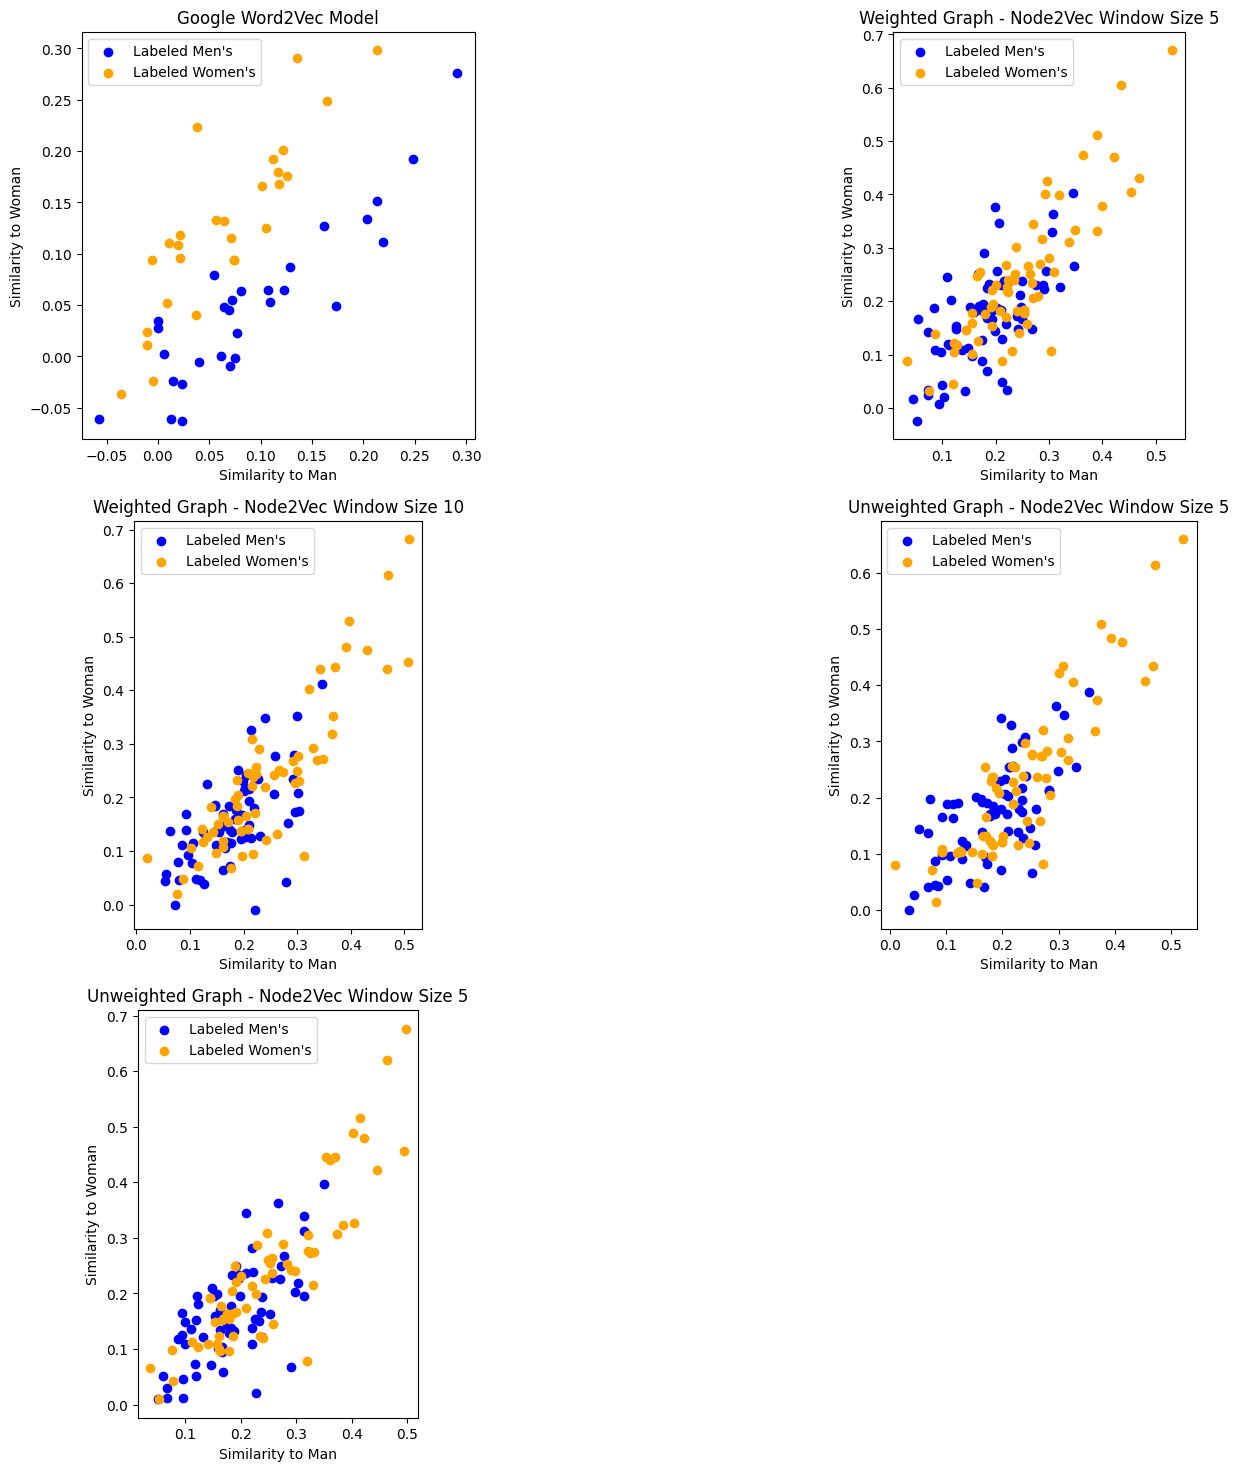

In [28]:
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
i, j = (0, 0)
for model_key, model in tqdm(models.items()):
    if model_key != 'google_word2vec':  
        man_key = "('man', 'n', 'singular', 'common')"
        woman_key = "('woman', 'n', 'singular', 'common')"
    else:
        man_key = 'man'
        woman_key = 'woman'
        
    man_emb = model[man_key]
    woman_emb = model[woman_key]
    magnitude_man = np.linalg.norm(man_emb)
    magnitude_woman = np.linalg.norm(woman_emb)

    mens_x = []
    mens_y = []

    womens_x = []
    womens_y = []
    
    for item in mens + womens:
        if model_key != 'google_word2vec':  
            nodes = [node for node in get_nodes(item) if 'UNK_POS' not in node]
        else:
            nodes = [item]

        for node in nodes:
            item_emb = model[node]
            magnitude_item = np.linalg.norm(item_emb)
            
            similarity_man = np.dot(item_emb, man_emb) / (magnitude_man * magnitude_item)
            similarity_woman = np.dot(item_emb, woman_emb) / (magnitude_woman * magnitude_item)
            #ax.annotate(node, (similarity_man, similarity_woman), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)
            if item in mens:
                mens_x.append(similarity_man)
                mens_y.append(similarity_woman)
            else:
                womens_x.append(similarity_man)
                womens_y.append(similarity_woman)

    ax = axs[i,j]
    ax.scatter(mens_x, mens_y, color='blue', label='Labeled Men\'s')
    ax.scatter(womens_x, womens_y, color='orange', label='Labeled Women\'s')
    ax.legend()
    ax.set_xlabel('Similarity to Man')
    ax.set_ylabel('Similarity to Woman')
    ax.set_title(plot_titles[model_key])
    ax.set_aspect('equal', adjustable='box')

    j = (j + 1) % 2
    if j == 0:
        i += 1

axs[2,1].set_visible(False)
    
plt.savefig('../figures/plot_of_bias.png')